In [84]:
import pandas as pd

df = pd.read_csv(r'C:\Users\MINA\Documents\WeekilyPrac\Ml_JOUNRAL\ml-learning-journal\Time Series\Datasets\sales.csv')

df.head()

,Date,Sales
0,2024-01-31,120
1,2024-02-29,125
2,2024-03-31,123
3,2024-04-30,130
4,2024-05-31,135


In [85]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

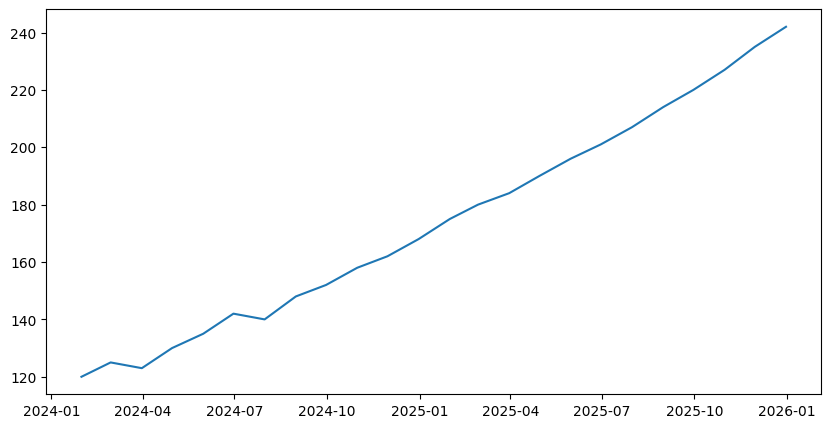

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Sales'])
plt.show()

In [87]:
df['Rolling_Mean'] = df['Sales'].rolling(window=3).mean()
df['Rolling_Std'] = df['Sales'].rolling(window=3).std()


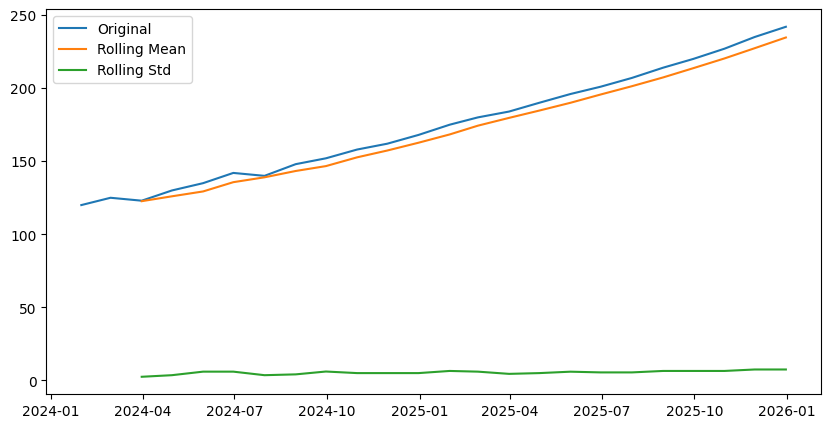

In [88]:
plt.figure(figsize=(10,5))

plt.plot(df['Sales'], label='Original')
plt.plot(df['Rolling_Mean'], label='Rolling Mean')
plt.plot(df['Rolling_Std'], label='Rolling Std')

plt.legend()
plt.show()

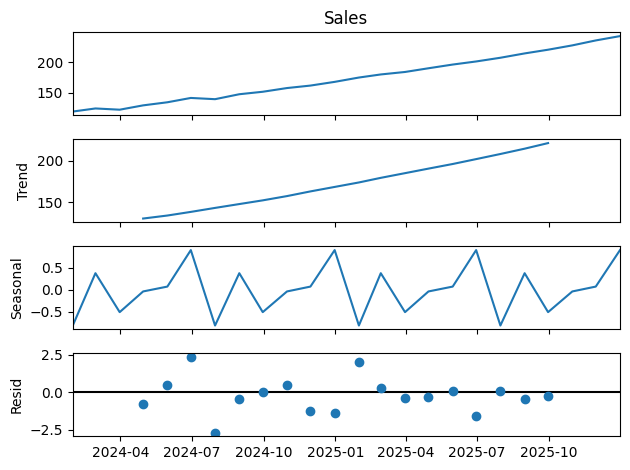

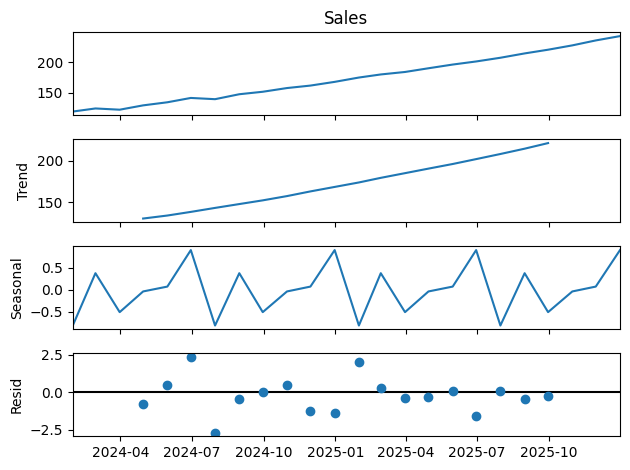

In [89]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(
    df['Sales'],
    model='addictive',
    period=6

)

decompose.plot()

In [90]:
from statsmodels.tsa.stattools import adfuller

results = adfuller(df['Sales'])

print(results[1])

if results[1] < 0.05:
    print('Stationary')
else:
    print('Not Stationary')



0.9990834791057953
Not Stationary


In [91]:
df['Sales_diff'] = df['Sales'].diff()

df_diff = df['Sales_diff'].dropna()



In [92]:
results = adfuller(df_diff)

print(results[1])

if results[1] < 0.05:
    print('Stationary')
else:
    print('Not Stationary')

0.9960869947590499
Not Stationary


In [93]:
df[['Sales', 'Sales_diff']].head(10)

,Sales,Sales_diff
Date,,
2024-01-31,120,NaN
2024-02-29,125,5.0
2024-03-31,123,-2.0
2024-04-30,130,7.0
2024-05-31,135,5.0
2024-06-30,142,7.0
2024-07-31,140,-2.0
2024-08-31,148,8.0
2024-09-30,152,4.0


In [94]:
df['Sales_diff2'] = df['Sales'].diff()

df_diff2 = df['Sales_diff2'].dropna()

results = adfuller(df_diff2)

print(results[1])

if results[1] < 0.05:
    print('Stationary')
else:
    print('Not Stationary')

0.9960869947590499
Not Stationary


### ACF AND PACF 

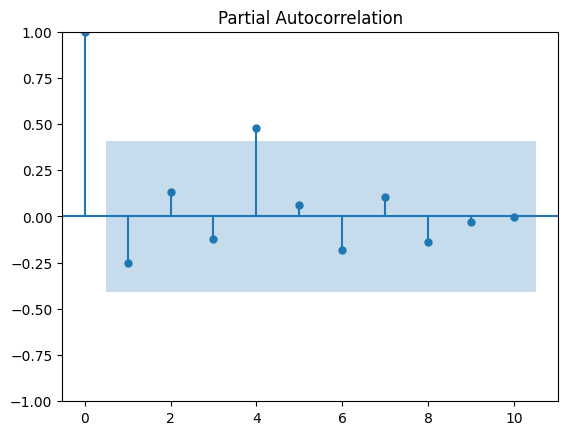

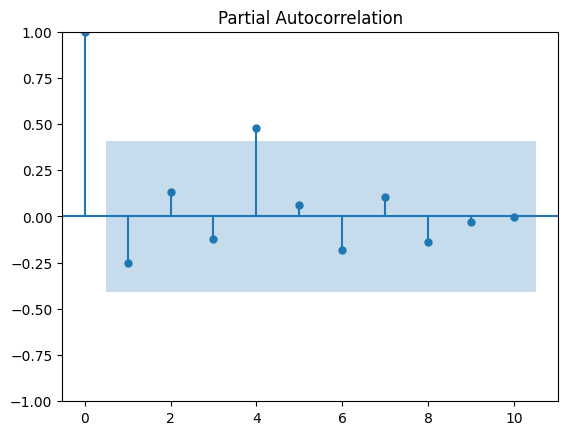

In [95]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

plot_pacf(df['Sales_diff2'].dropna(),lags=10)


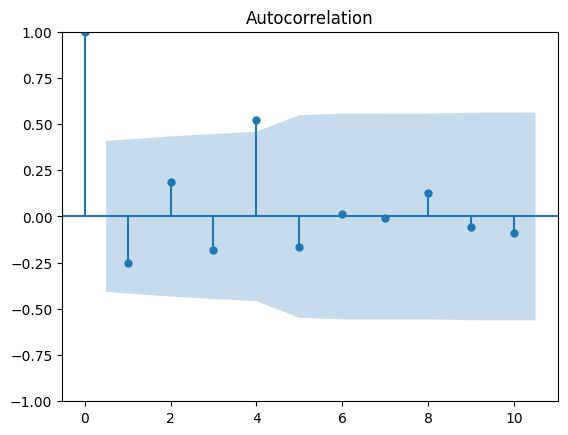

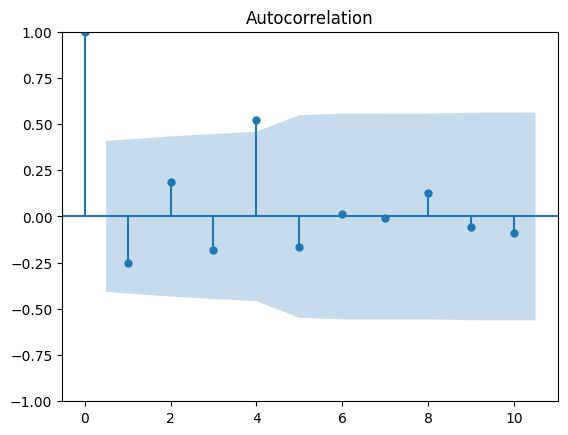

In [96]:
plot_acf(df['Sales_diff2'].dropna(),lags=10)

### Train/Test Split

In [97]:
train = df.iloc[:-6]
test = df.iloc[-6:]

In [98]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Sales'],order=(1,2,1))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


### Forecast

In [99]:
forecast = model_fit.forecast(steps=6)

forecast

2025-07-31    206.418530
2025-08-31    211.644281
2025-09-30    216.958828
2025-10-31    222.232475
2025-11-30    227.524961
2025-12-31    232.808770
Freq: ME, Name: predicted_mean, dtype: float64

In [100]:
comparison = pd.DataFrame({
    'Actual':test['Sales'],
    'Forecast': forecast
})

comparison

,Actual,Forecast
2025-07-31,207,206.418530
2025-08-31,214,211.644281
2025-09-30,220,216.958828
2025-10-31,227,222.232475
2025-11-30,235,227.524961
2025-12-31,242,232.808770


### Evaluate

In [102]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test['Sales'],
    forecast
)

rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))

print('MAE ',mae)
print('RMSE :',rmse)

MAE  4.568692315158695
RMSE : 5.450083415561237


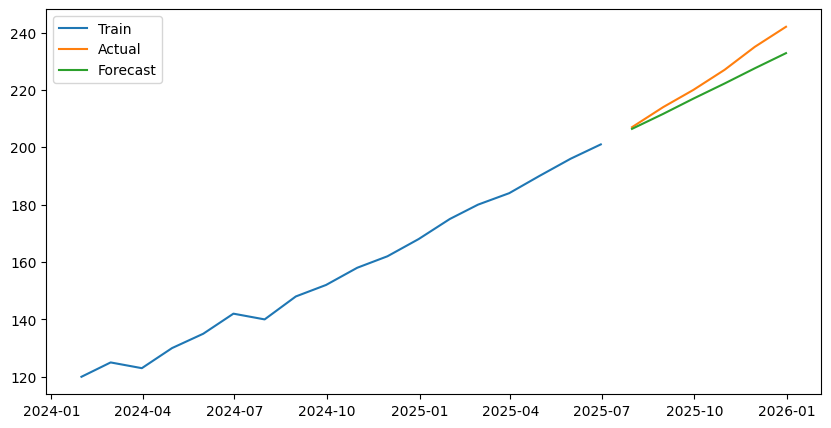

In [104]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.show()